In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
import os

cwd = os.getcwd()
cwd

'C:\\Users\\Sabrina\\Desktop\\Datasets\\Espresso Blend Brew data'

In [42]:
df = pd.read_csv('espresso_brew_v2.csv')
df

,Origin,Caffeine,Roast level,Roaster,Product weight (grams),Tasting notes,Rating,Time rested (days),Dose (grams),Yield (grams),Brew ratio,Shot time (seconds),Espresso machine,Grinder,Grind setting,Water temperature (°C)
0,Colombia,1,2.0,Monogram,300.0,"['Rum ', ' brown sugar']",9.0,7.0,18.0,45.0,1:2.5,30,ECM Synchronika,Monolith MAX Gen 1,1.75,93.8
1,Colombia,1,2.0,DAK,1000.0,"['Cardamom', ' vanilla', ' nuts']",10.0,5.0,18.0,45.0,1:2.5,30-35,ECM Synchronika,Monolith MAX Gen 1,NaN,94.4
2,Blend,1,4.0,Cat & Cloud,283.0,['Smooth'],8.0,5.0,16.3,33.0,1:2.0,30,DeLonghi ECP 35.31,Baratza Encore ESP,17,NaN
3,Blend,1,5.0,Onyx,283.0,"['Chocolate', ' nuts', ' low acidity']",7.0,5.0,18.0,36.0,1:2.0,25-35,La Marzocco Linea Micra,1zpresso J-Ultra,1.35,95.0
4,Blend,1,4.0,Black & White,340.0,"['Funky', ' slightly acidic']",3.0,14.0,18.0,45.0,1:2.5,25-35,La Marzocco Linea Micra,1Zpresso J-Ultra,1.25,95.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,Ethiopia,1,3.0,Gracenote Coffee,340.0,"['Blueberry cobbler', 'pie', ' chocolate']",8.0,6.0,16.5,35.5,1:2.2,45,ECM Synchronika II,Zerno Z1,130 nm,94.0
216,Blend,1,3.0,Ember and Bean Roasting Co,340.0,NaN,8.0,NaN,19.0,45.0,1:2.4,35,Breville Bambino Plus,Baratza Encore ESP,NaN,NaN
217,Ethiopia,1,3.0,Press Coffee,340.0,NaN,8.0,NaN,18.0,36.0,1:2.0,30,Flair Pro 3,DF64,21.5,96.0
218,Brazil,1,4.0,Origins Roastery,1000.0,['toffee'],7.0,8.0,17.0,33.0,1:1.9,28-30,Sanremo You,Eureka Helios,NaN,96.0


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Origin                  220 non-null    object 
 1   Caffeine                220 non-null    int64  
 2   Roast level             219 non-null    float64
 3   Roaster                 220 non-null    object 
 4   Product weight (grams)  212 non-null    float64
 5   Tasting notes           201 non-null    object 
 6   Rating                  218 non-null    float64
 7   Time rested (days)      181 non-null    float64
 8   Dose (grams)            220 non-null    float64
 9   Yield (grams)           220 non-null    float64
 10  Brew ratio              220 non-null    object 
 11  Shot time (seconds)     219 non-null    object 
 12  Espresso machine        219 non-null    object 
 13  Grinder                 220 non-null    object 
 14  Grind setting           189 non-null    ob

The dataset that has been cleaned and prepared was taken from a Reddit post where people were asked to record their espresso brew recipes.It consists of 220 entries that comprise data types like **float64(7), int64(1), and object(8)**. The features in this dataset includes those that are inherent to the bean or blend. This includes **'Origin'** (where the bean came from), **'Caffeine'** (Caffeine present or Decaf), **'Roast level'**(On a scale of 1-7), **'Roaster'**(The company who roasted the beans), **'Roater_Country'** (the country where the roaster was located), **'Product weight'** (this is the weight of the product in grams). </br>
</br>
Additionally, there are features that pertain more to the brew recipe. This consists of **'Tasting notes'** (espresso flavor profile, based on personal recipe), **'Rating'** (the score given to the brew), **'Time rested (days)'** (This is the time given in days for freshly roasted beans to degas), **'Dose (grams)'** (this is the dosage that was pulled for extraction, **'Yield (grams)'** (this refers to the amount of espresso that was extracted, **'Brew ratio'** (this is the proportion of coffee to water), **'Shot time(seconds)'** (this refers to how long it took for the shot to be pulled). </br>
</br>
Additional features that can impact the score involve the instruments used, such as, **'Espresso machine'**, **'Grinder'**, **'Grind setting'**, **'Water temperature (C)'**, and **'Basket specs'** (this refers to the espresso basket used).

## What does the Origin distribution look like?

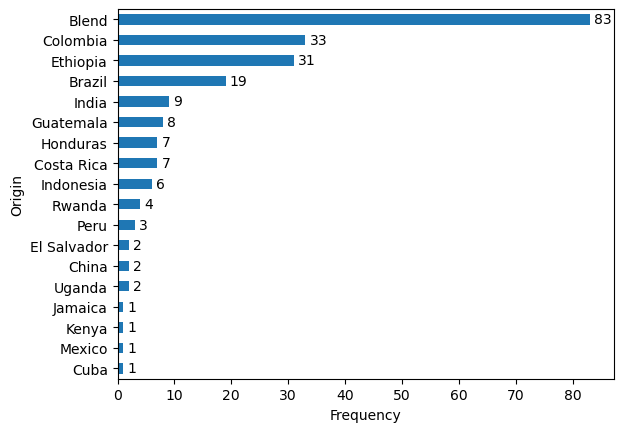

In [54]:
ax = df['Origin'].value_counts(ascending=True).plot(kind='barh')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.xlabel('Frequency')
plt.show()

The data shows that 83 out of the 220 entries are blends, meaning that beans of different regions were mixed. In regard to single-origin beans, the top 3 countries of origin are Columbia with 33 entries, Ethiopia with 31 entries, and Brazil with 19 entries.

### What does Roaster distribution look like?

In [60]:
df['Roaster'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 220 entries, 0 to 219
Series name: Roaster
Non-Null Count  Dtype 
--------------  ----- 
220 non-null    object
dtypes: object(1)
memory usage: 1.8+ KB


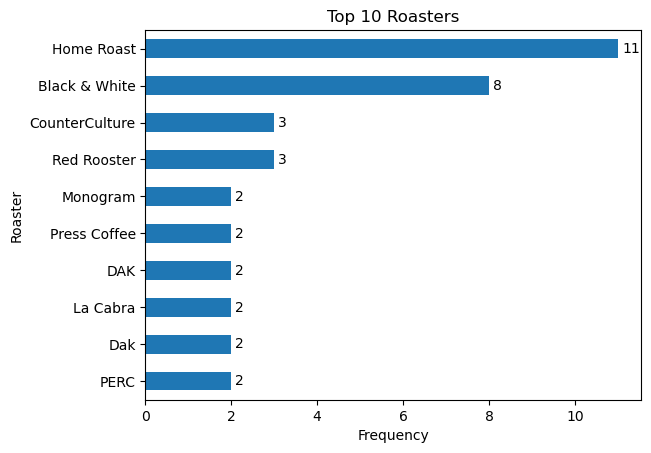

In [89]:
ax = df['Roaster'].value_counts().head(10).plot(kind='barh')

ax.invert_yaxis()

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.xlabel('Frequency')
plt.title('Top 10 Roasters')
plt.show()

This data shows that **Home Roast** is the roaster who had the most entries (11), followed by **Black & White** with 8 entries, and CounterCulture and Red Rooster with 3 entries.

### What does the distribution of the Roaster countries look like?

In [11]:
Roaster_Country = pd.read_csv('Roaster_Country.csv')
Roaster_Country.head()

,Roaster_Country
0,Canada
1,Netherlands
2,United States
3,United States
4,United States


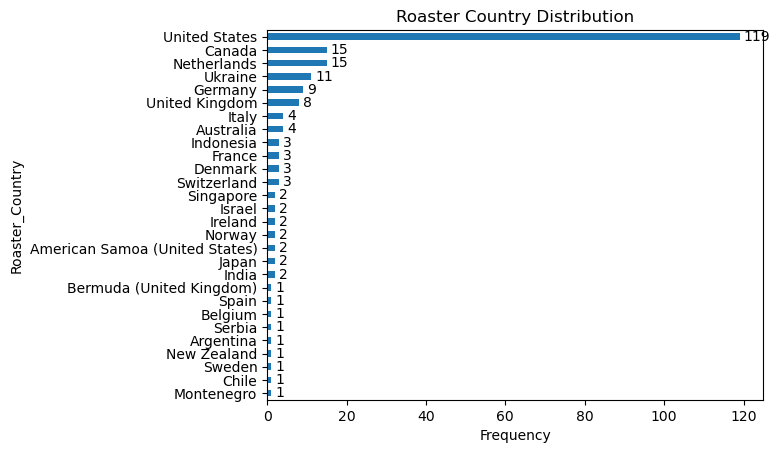

In [93]:
# Visualize the frequencies of different countries in dataset

ax = Roaster_Country['Roaster_Country'].value_counts(ascending=True).plot(kind='barh')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.xlabel('Frequency')
plt.title('Roaster Country Distribution')
plt.show()


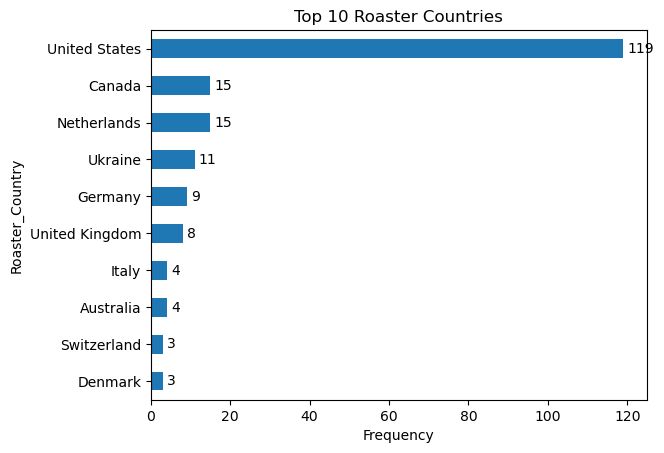

In [97]:
# Visualize the frequencies of different countries in dataset

ax = Roaster_Country['Roaster_Country'].value_counts().head(10).plot(kind='barh')

ax.invert_yaxis()

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.xlabel('Frequency')
plt.title('Top 10 Roaster Countries')
plt.show()


The Top 5 countries in this list includes the **United States** with 119 entries, **Canada** with 15 entries, **Netherlands** with 15 entries, **Ukraine** with 15 entries, and **Germany** with 9 entries.

## What is the average roast level recorded? What is the highest? What is the lowest?

In [100]:
df['Roast level'].describe()

count    219.000000
mean       3.538813
std        1.314039
min        1.000000
25%        3.000000
50%        3.000000
75%        4.000000
max        7.000000
Name: Roast level, dtype: float64

The **average roast** level recorded is at **3**. The **highest** score recorded is at **7**, while the **lowest** is at **1**. 
</br>
### What does the distribution of roast levels look like?

In [117]:
df['Roast level'] = df['Roast level'].fillna(df['Roast level'].median())


In [119]:
df['Roast level'] = df['Roast level'].astype(int)

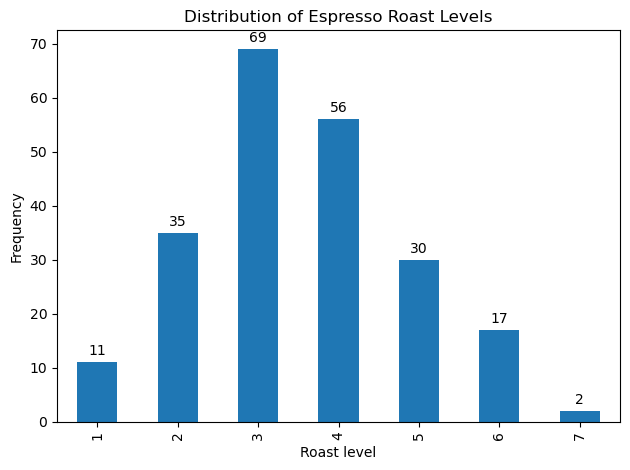

In [139]:
ax = df['Roast level'].value_counts().sort_index().plot(kind='bar')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Distribution of Espresso Roast Levels')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

This data shows that a majority of the beans have a roast level of 3, followed closely by a roast level of 4. This can be a more medium roast, whereas the lower levels are akin to lighters roasts, and higher levels to darker roasts.